# Algoritmul Min-Max

**MAX** -> jucătorul care încearcă să-şi maximizeze scorul

**MIN** -> oponentul care încearcă să minimizeze scorul lui MAX

 Paşi:

 1. Generează arborele de joc până la stările scop sau o adâncime stabilită.

 2. Estimează scorul fiecărei stări terminale (frunze).

 3. Deplasează-te înapoi în arbore, de la nodurile frunze spre nodul rădăcină, determinând la fiecare nivel al arborelui valorile care reprezintă utilitatea (i.e. scorul) nodurilor aflate la acel nivel.

 Propagarea acestor valori la nivelurile anterioare se face prin intermediul nodurilor-părinte conform următoarei reguli:

   - dacă părintele este un nod de tip MAX, atribuie-i maximul dintre valorile fiiilor săi;
   - dacă părintele este un nod de tip MIN, atribuie-i minimul dintre valorile fiilor săi.

 4. Ajuns în nodul-rădăcină, alege pentru MAX acea mutare care
 conduce la valoarea maximă.


## 1. Min-Max

Implementați algoritmul Min-Max. Cât va fi valoarea lui Max pentru arborele din imagine?

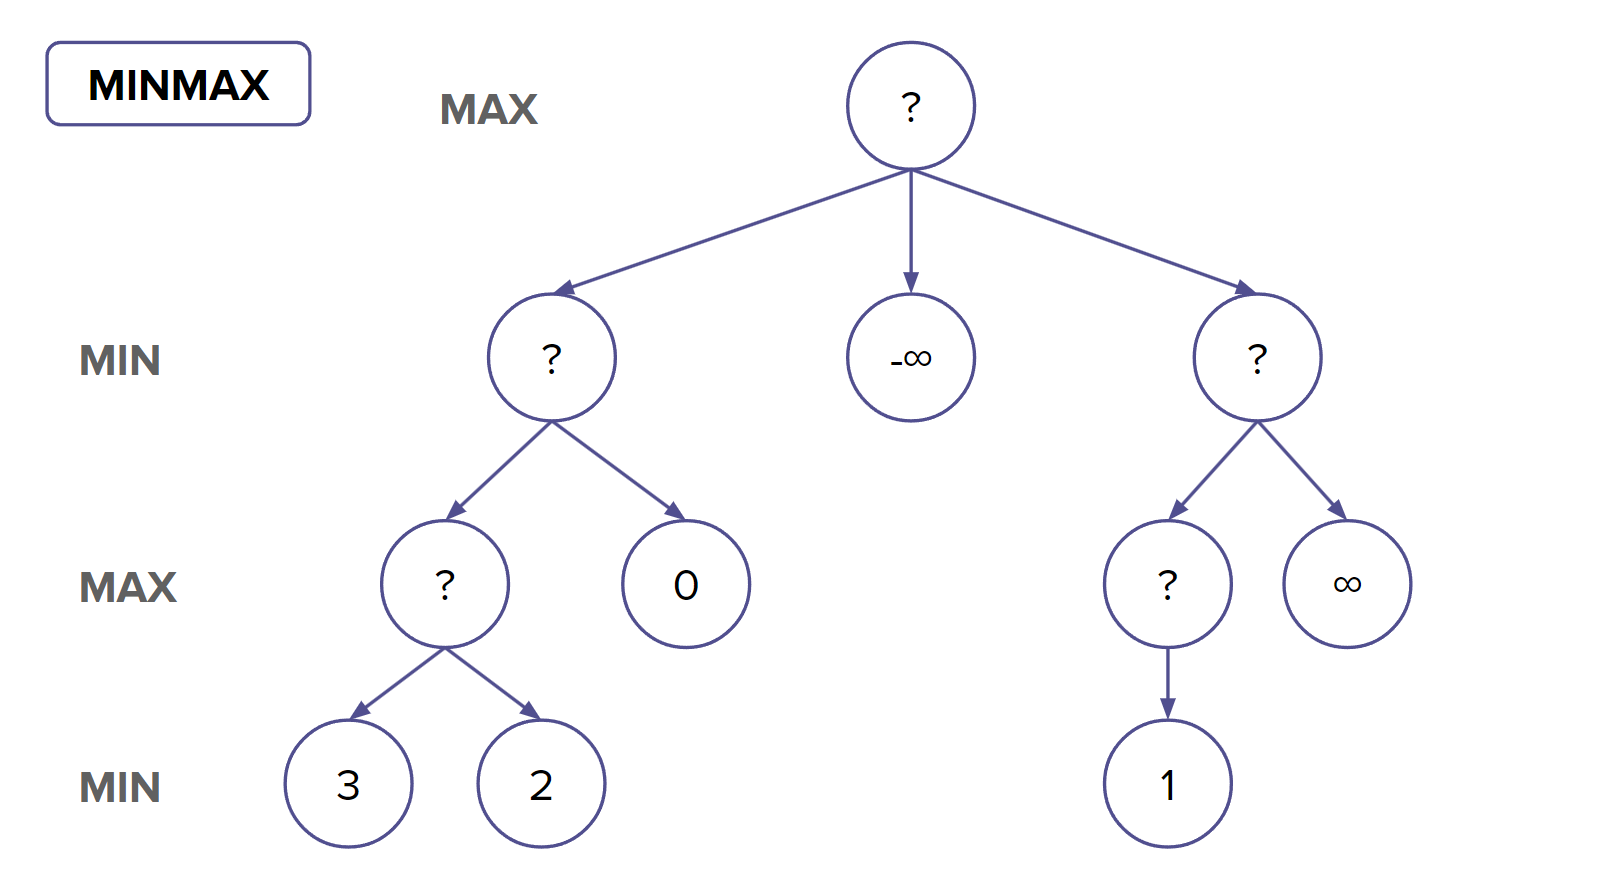

In [8]:
from __future__ import annotations
class Nod:
    def __init__(self, informatie , parinte=None):
        self.informatie = informatie
        self.parinte = parinte

    def drumRadacina(self):
        nod_curent = self
        drum = []
        while nod_curent is not None:
            drum.insert(0, nod_curent)
            nod_curent = nod_curent.parinte
        return drum

    def vizitat(self):
        nod_curent = self.parinte
        while nod_curent is not None:
            if nod_curent.informatie == self.informatie:
                return True
            nod_curent = nod_curent.parinte
        return False

    def __str__(self):
        drum = self.drumRadacina()
        drum_str = " -> ".join([str(n.informatie) for n in drum])
        return f"{self.informatie} ({drum_str})"

    def __repr__(self):
        return str(self)

    def __eq__(self, other: Nod) -> bool:
        return self.informatie == other.informatie


class Graf:
    def __init__(self, nodStart, noduriScop, muchii, euristica):
        self.nodStart = Nod(informatie=nodStart)
        self.noduriScop = noduriScop
        self.euristica = euristica
        self.muchii = {}
        for sursa, destinatie in muchii:
            if sursa not in self.muchii:
                self.muchii[sursa] = []
            self.muchii[sursa].append(destinatie)

    def scop(self, informatie_nod):
        return informatie_nod in self.noduriScop

    def estimeaza_h(self, nod : Nod):
        return self.euristica.get(nod.informatie, 0)

    def succesori(self, nod_curent):
        lista_succesori = []

        vecini = self.muchii.get(nod_curent.informatie, [])

        for informatie_vecin in vecini:
            nod_nou = Nod(informatie=informatie_vecin, parinte=nod_curent)

            if not nod_nou.vizitat():
                lista_succesori.append(nod_nou)

        return lista_succesori

In [9]:
graf = Graf(0,
            [2, 5, 7, 8, 9, 10],
            [(0, 1), (0, 2), (0, 3), (1, 4), (1, 5),
             (3, 6), (3, 7), (4, 8), (4, 9), (6, 10)],
            {2: -float('inf'), 5: 0, 7: float('inf'), 8: 3, 9: 2, 10: 1})

In [16]:
def min_max(nodCurent, jucator, graf, adancime=10):
    if graf.scop(nodCurent.informatie) or adancime == 0:
        return graf.estimeaza_h(nodCurent)

    if jucator == "MAX":
        best_val = float('-INF')
        succ = graf.succesori(nodCurent)

        for s in succ:
            val = min_max(s, 'MIN', graf, adancime - 1)
            best_val = max(best_val, val)

        return best_val
    else:
        best_val = float('INF')
        succ = graf.succesori(nodCurent)

        for s in succ:
            val = min_max(s, 'MAX', graf, adancime - 1)
            best_val = min(best_val, val)

        return best_val

In [17]:
min_max(graf.nodStart, 'MAX', graf)

1

## 2. Pregătirea contextului pentru jocul X & 0

Vom ține minte static în clasa Game:
- simbolul lui MAX
- simbolul lui MIN
- simbolul pentru spațiu GOL pe tablă

La inițializare constructorul va copia tabla dată ca parametru dacă există sau va crea o tablă de joc goală altfel.

Metode:
- *jucator_opus(jucator)* - primește simbolul jucătorului curent și întoarce simbolul jucătorului opus
- *succesori(nod)* - la fel ca până acum, metoda va genera lista completă de mutări posibile din starea curentă (fără repetiție)
- *scop(nod)* - verifică dacă am ajuns într-o stare finală. Dacă da, va returna simbolul câștigătorului dacă există unul, "remiză" altfel

In [31]:
import copy

class Game:
    MAX = 'X'
    MIN = '0'
    GOL = '.'

    def __init__(self, tabla=None):
        if tabla is None:
            self.tabla = [[Game.GOL for _ in range(3)] for _ in range(3)]
        else:
            self.tabla = copy.deepcopy(tabla)

    def jucator_opus(self, jucator):
        return Game.MIN if jucator == Game.MAX else Game.MAX

    def succesori(self, jucator):
        lista_mutari = []
        for i in range(3):
            for j in range(3):
                if self.tabla[i][j] == Game.GOL:
                    new_tabla = copy.deepcopy(self.tabla)
                    new_tabla[i][j] = jucator
                    lista_mutari.append(Game(new_tabla))
        return lista_mutari

    def linii_coloane_diag(self):
        linii = self.tabla
        coloane = [[self.tabla[r][c] for r in range(3)] for c in range(3)]
        diag_principala = [self.tabla[i][i] for i in range(3)]
        diag_secundara = [self.tabla[i][2 - i] for i in range(3)]
        return linii + coloane + [diag_principala, diag_secundara]

    def scop(self):
        combinatii = self.linii_coloane_diag()

        for linie in combinatii:
            if linie[0] != Game.GOL and linie[0] == linie[1] == linie[2]:
                return linie[0]

        for rand in self.tabla:
            if Game.GOL in rand:
                return False  # jocul continua

        return "remiza"


    def __repr__(self):
        return '\n'.join(['|'.join(rand) for rand in self.tabla])



In [33]:
g = Game()
print(g)
print(g.succesori(g.MAX))

.|.|.
.|.|.
.|.|.
[X|.|.
.|.|.
.|.|., .|X|.
.|.|.
.|.|., .|.|X
.|.|.
.|.|., .|.|.
X|.|.
.|.|., .|.|.
.|X|.
.|.|., .|.|.
.|.|X
.|.|., .|.|.
.|.|.
X|.|., .|.|.
.|.|.
.|X|., .|.|.
.|.|.
.|.|X]


In [ ]:
class NodX0:
    def __init__(self, state, parinte=None):
        self.informatie = state
        self.parinte = parinte
        self.euristica = None
        self.succesori = []
        self.cel_mai_bun_succesor = None

    def scor_linie(self, linie):
        nr_x = linie.count(Game.MAX)
        nr_0 = linie.count(Game.MIN)

        if nr_x > 0 and nr_0 > 0:
            return 0

        punctaj = {0: 0, 1: 1, 2: 10, 3: 100}

        if nr_x > 0:
            return punctaj[nr_x]
        if nr_0 > 0:
            return -punctaj[nr_0]

        return 0

    def calculeaza_euristica(self):
        scor = 0
        for linie in self.informatie.linii_coloane_diag():
            scor += self.scor_linie(linie)

        self.euristica = scor
        return self.euristica

    def __str__(self):
        return str(self.informatie)

    def __repr__(self):
        return str(self)


class GrafX0:
    def __init__(self):
        self.nodStart = NodX0(Game())

    def succesori(self, nod_curent, jucator):
        stari_urmatoare = nod_curent.informatie.succesori(jucator)
        return [NodX0(stare, parinte=nod_curent) for stare in stari_urmatoare]

    def minmax(self, nod, adancime, is_max):
        if adancime == 0 or nod.informatie.scop() is not False:
            nod.calculeaza_euristica()
            return nod

        if is_max:
            nod.succesori = self.succesori(nod, Game.MAX)

            best_score = float('-inf')
            best_child = None

            for succesor in nod.succesori:
                self.minmax(succesor, adancime - 1, False)

                if succesor.euristica > best_score:
                    best_score = succesor.euristica
                    best_child = succesor

            nod.euristica = best_score
            nod.cel_mai_bun_succesor = best_child
            return nod

        else:
            nod.succesori = self.succesori(nod, Game.MIN)

            best_score = float('inf')
            best_child = None

            for succesor in nod.succesori:
                self.minmax(succesor, adancime - 1, True)

                if succesor.euristica < best_score:
                    best_score = succesor.euristica
                    best_child = succesor

            nod.euristica = best_score
            nod.cel_mai_bun_succesor = best_child
            return nod

In [38]:
graf = GrafX0()
nod = graf.minmax(graf.nodStart, 3, True)
print(nod.cel_mai_bun_succesor) # starea terminala cea mai avantajoasa de la nivelul 3
print(nod.euristica)

.|.|.
.|X|.
.|.|.
12


## 3. Min-Max aplicat pe X & 0

Implementați funcția *minmax()* care primește un obiect de tip nod al arborelui și, dacă e stare finală sau a ajuns la adâncimea maximă, îi calculează estimarea. Dacă e stare intermediară, îi calculează succesorii dintre care îl alege pe cel mai bun în funcție de tipul de nod (MIN sau MAX).
<!--  -->
Vom considera estimarea scorului pentru simbolul X:
- pentru fiecare simbol X aflat singur pe o linie / coloană / diagonală se adună 1 punct la scor
- pentru fiecare 2 simboluri X aflate singure pe o linie / coloană / diagonală se adună 10 puncte la scor
- pentru fiecare combinație de 3 X-uri în linie / coloană / diagonală se adună 100 de puncte
- din acest scor se scade echivalentul pe 0

Pentru 0 estimarea este 0 - estimarea pe X.